In [1]:
import uproot
import matplotlib
import pandas as pd
import numpy as np
from tqdm import tqdm
import dask.dataframe as dd
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import glob
import boost_histogram as bh
import os
import re
from multihist import Histdd
from tqdm import tqdm

### Helper Functions

In [2]:
#############################
# Energy Resolution Function
#############################

# Function taken from from XENON1T 
def energy_res(energy, a_res=0.317, b_res=1.7):
    resolution = a_res*np.sqrt(energy)+b_res*10**-3*energy
    e_smeared = np.random.normal(energy,resolution)
    return e_smeared

In [3]:
#############################
# Activity/Isotope/Vol Dict
#############################

act_dict = {'PMT': {'Co60': 700, 'U238': 8000, 'Th232': 500},
            'Sapphire': {'Co60': 0.0, 'U238': 90, 'Th232': 60},
            'PTFE': {'Co60': 50.0, 'U238': 150, 'Th232':50},
            'Cryostat': {'Co60': 3000, 'U238': 4000, 'Th232':2000},
           }

#############################
# Volume Mass Dict
#############################

mass_dict = {'PMT': 2240, 'Sapphire': 45, 'PTFE':200, 'Cryostat': 4000}

In [4]:
# Assumed thsi number is tracked. Best to get info directly from files later.
num_primaries_perfile = {'PMT': 250000, 'PTFE': 250000, 'Cryostat': 250000, 'Sapphire': 250000}

In [5]:
#Combine Mass and Activity dicts to determine Scaling Factors

scale_dict = {}
for key, volume in act_dict.items():
    volume_scale = {}
    for act_key, activity in volume.items(): 
        #print(act_key)
        if (act_dict[key][act_key])>0:
            scale_factor = num_primaries_perfile[key]/(mass_dict[key]*act_dict[key][act_key]*10e-6)
        else:
            scale_factor=0
        volume_scale[act_key] = scale_factor
        #print(scale_factor)
    scale_dict[key] = volume_scale

In [6]:
#############################
# Selection Functions
#############################
def select_ss_ms_events(df):
    # For each runid, for each eventid, select clusters with only one cluster_id (single scatter)
    ss_events = df[df['nclusters'] == 1]
    ms_events = df[df['nclusters'] > 1]
    
    return ss_events, ms_events

def select_events_in_energy_range(df, energy_range=(4, 50)):
    # energy ROI cut
    # NR: (4, 50) keV -> ER: (1, 12) keV
    return df[df["edep"].between(*energy_range)]

# and occur inside the fiducial volume and within the energy ROI
def select_events_in_roi(df, fv_z, fv_radius, energy_range=(4, 50)):
    # Apply fiducial volume cut
    events_fv = df[df["zp"].between(*fv_z) & (df["xp"]**2 + df["yp"]**2 <= fv_radius**2)]
    events_roi = select_events_in_energy_range(events_fv, energy_range=energy_range)
    return events_roi

### Raw Distributions

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [05:07<00:00,  3.25it/s]
0it [00:00, ?it/s]


No files found for key PTFE, isotope U238


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1002/1002 [02:36<00:00,  6.41it/s]


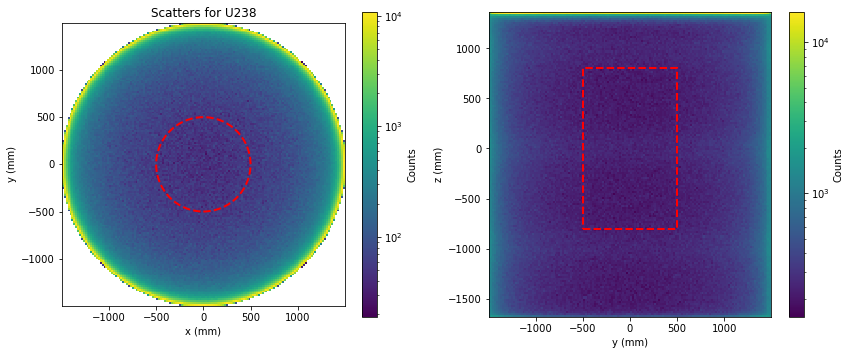

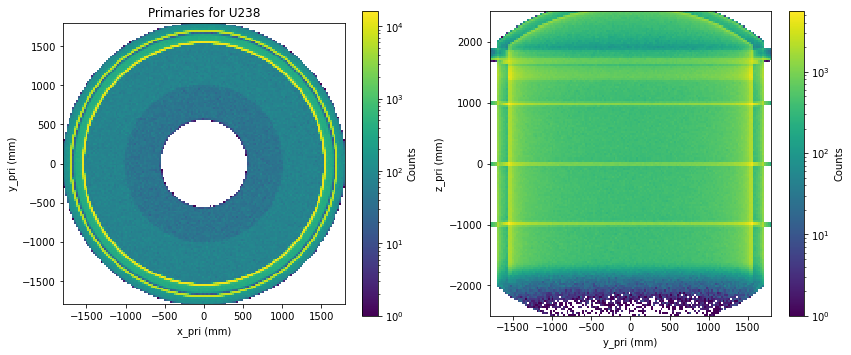

0


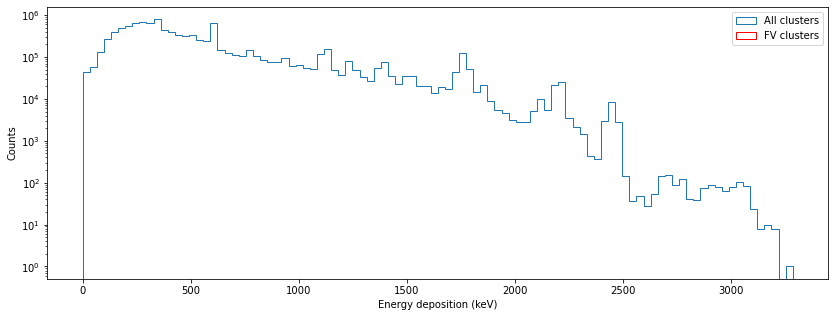

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [04:30<00:00,  3.69it/s]
0it [00:00, ?it/s]


No files found for key PTFE, isotope Th232


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:09<00:00,  7.74it/s]


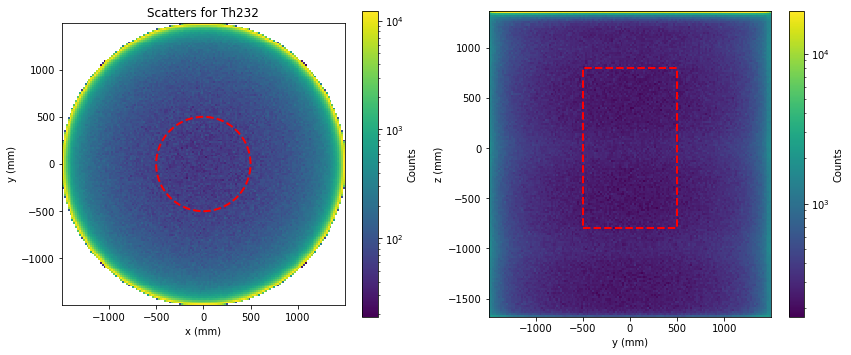

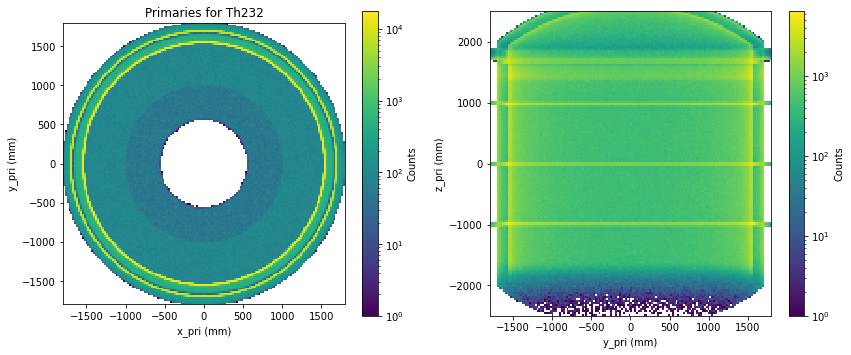

1


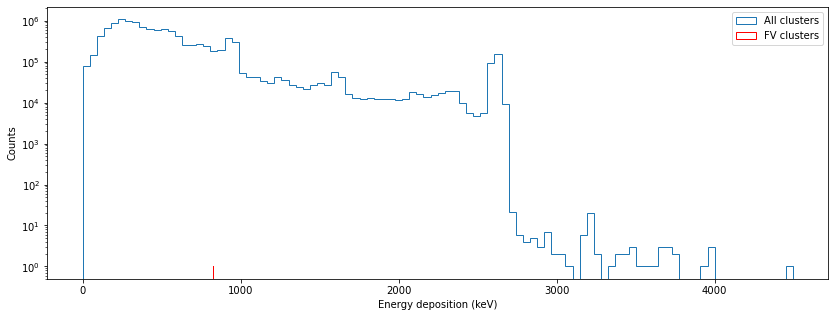

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [04:03<00:00,  4.10it/s]
0it [00:00, ?it/s]


No files found for key PTFE, isotope Co60


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:12<00:00,  7.52it/s]


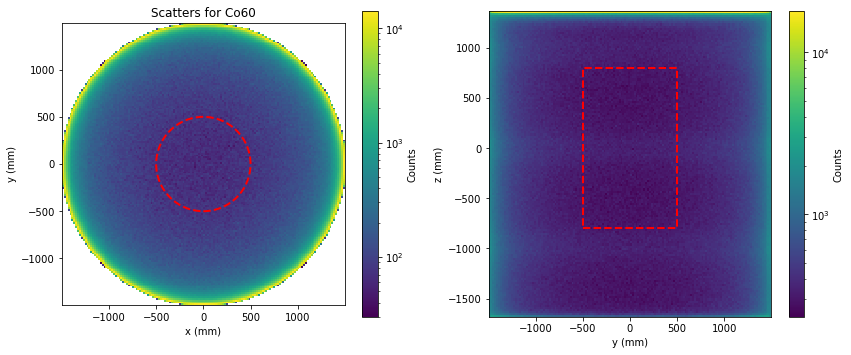

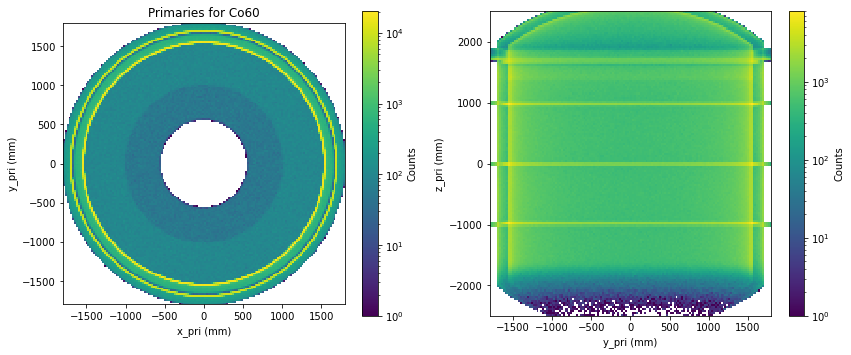

2


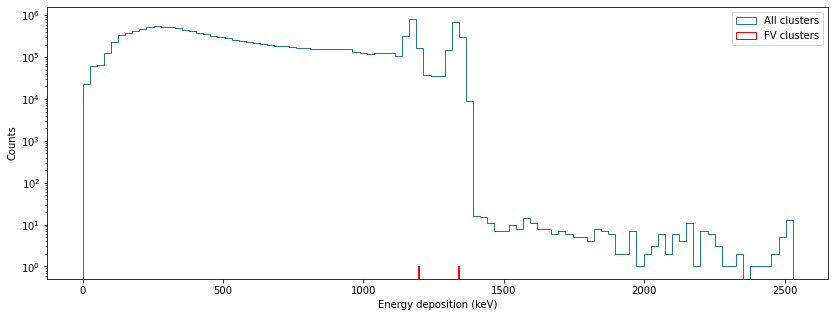

In [9]:
file_prefix = ''
fv_x = 500  # mm
fv_z = (-800, 800)  # mm
max_index=1500

for isotope in ['U238', 'Th232', 'Co60']:
    for key, volume in act_dict.items():
        all_dfs = []
    
        # Search for all files matching the pattern for this key + isotope
        #file_pattern = f'/storage/xenon/jacquesp/hermeticTPC/{key}_{isotope}_*.parquet'
        file_pattern = f'/storage/xenon/nadavh/hermeticTPC/BigStats_01/{key}/{isotope}/{key}_{isotope}_*_s10mm.parquet'
        matched_files_n = sorted(glob.glob(file_pattern))
        file_pattern = f'/storage/xenon/jacquesp/hermeticTPC/BigStats_01/{key}/{isotope}/{key}_{isotope}_*_s10mm.parquet'
        matched_files_j = sorted(glob.glob(file_pattern))
        matched_files = np.concatenate([matched_files_j,matched_files_n])
        
        for filepath in tqdm(matched_files):
            filename = os.path.basename(filepath)
    
            # Use regex to extract serial number (handles zero-padding)
            match = re.match(rf'{re.escape(file_prefix)}{re.escape(key)}_{re.escape(isotope)}_(\d+)\_s10mm.parquet', filename)
            if match:
                serial_num = int(match.group(1))
                if serial_num > max_index:
                    continue
    
                # Load and collect DataFrame
                iso_vol_df = pd.read_parquet(filepath)

                #Find Single Scatters
                iso_vol_df = iso_vol_df[iso_vol_df['nclusters']==1]
                all_dfs.append(iso_vol_df)
                
            else:
                print(f"Skipping file (name format doesn't match): {filename}")
    
        # Concatenate all matching DataFrames
        if not all_dfs:
            print(f"No files found for key {key}, isotope {isotope}")
            continue

        file_loaded_counter = len(all_dfs)
        fuse_data = pd.concat(all_dfs, ignore_index=True)
    
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    hxy = ax1.hist2d(fuse_data["xp"], fuse_data["yp"], bins=150, norm=matplotlib.colors.LogNorm())
    ax1.set_title(f"Scatters for {isotope}")
    ax1.set_xlabel("x (mm)")
    ax1.set_ylabel("y (mm)")
    ax1.set_aspect('equal', adjustable='box')

    hyz = ax2.hist2d(fuse_data["yp"], fuse_data["zp"], bins=150, norm=matplotlib.colors.LogNorm())
    #ax2.set_title(f"Fuse Cluster for {key}")
    ax2.set_xlabel("y (mm)")
    ax2.set_ylabel("z (mm)")
    #ax2.set_aspect('equal', adjustable='box')

    # make a box for the fiducial volume
    ax1.add_patch(plt.Circle((0, 0), fv_x, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))
    ax2.add_patch(plt.Rectangle((-fv_x, fv_z[0]), 2*fv_x, 2*fv_z[1], color='red', fill=False, linestyle='--', linewidth=2))

    fig.colorbar(hxy[3], label="Counts")
    fig.colorbar(hyz[3], label="Counts")
    fig.tight_layout()

    plt.show()


    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    hxy = ax1.hist2d(fuse_data["xp_pri"], fuse_data["yp_pri"], bins=150, norm=matplotlib.colors.LogNorm())
    ax1.set_title(f"Primaries for {isotope}")
    ax1.set_xlabel("x_pri (mm)")
    ax1.set_ylabel("y_pri (mm)")
    ax1.set_aspect('equal', adjustable='box')

    hyz = ax2.hist2d(fuse_data["yp_pri"], fuse_data["zp_pri"], bins=150, norm=matplotlib.colors.LogNorm())
    #ax2.set_title(f"Fuse Cluster for {key}")
    ax2.set_xlabel("y_pri (mm)")
    ax2.set_ylabel("z_pri (mm)")
    #ax2.set_aspect('equal', adjustable='box')

    fig.colorbar(hxy[3], label="Counts")
    fig.colorbar(hyz[3], label="Counts")
    fig.tight_layout()

    plt.show()


    fig = plt.figure(figsize=(14,5))
    plt.hist(energy_res(fuse_data["edep"], 0.317, 1.7), bins=100, histtype='step', label='All clusters')

    data_fv = energy_res(fuse_data[fuse_data["zp"].between(*fv_z) & (fuse_data["xp"]**2 + fuse_data["yp"]**2 <= fv_x**2)]["edep"], 0.317, 1.7)
    print(len(data_fv))
    plt.hist(data_fv, bins=100, histtype='step', label='FV clusters', color='red')

    plt.legend()

    plt.xlabel("Energy deposition (keV)")
    plt.ylabel("Counts")
    plt.yscale("log")

    plt.show()

### Rate Plots

In [10]:
LXe = {
    "density": 2.862, # g/cm3
    "temperature": 177.05, # K
    "pressure": 1.5 # bar
}

TPC_dimensions = {
    "radius": 1500, # mm
    "top": 1365, # mm
    "bottom": -1682, # mm
}
TPC_center = [0, 0, TPC_dimensions["top"]-(TPC_dimensions["top"] - TPC_dimensions["bottom"]) / 2]

In [72]:
file_prefix = ''

#Max Files
max_index=1500

#Scaling Settings
year = 3.154e7  #seconds
estimates = {}
fv_radius = TPC_dimensions['radius']
fv_z = [TPC_dimensions['bottom'], TPC_dimensions['top']]
height =(fv_z[1]-fv_z[0])
volume = height/10*np.pi*(fv_radius/10)**2
fv_mass = (volume*LXe['density'])/1e6
_erange = (0, 200)

energy_binning = np.linspace(2000, 3000, 101)
for isotope in ['U238', 'Th232', 'Co60']:
    background_hist = Histdd(bins=[energy_binning])
    binwidth = background_hist.bin_centers(0)[1]-background_hist.bin_centers(0)[0]
    errors=np.zeros_like(background_hist.bin_centers(0))
    for key, volume in act_dict.items():
        all_dfs = []
    
        # Search for all files matching the pattern for this key + isotope
        #file_pattern = f'/storage/xenon/jacquesp/hermeticTPC/{key}_{isotope}_*.parquet'
        file_pattern = f'/storage/xenon/nadavh/hermeticTPC/BigStats_01/{key}/{isotope}/{key}_{isotope}_*_s10mm.parquet'
        matched_files_n = sorted(glob.glob(file_pattern))
        file_pattern = f'/storage/xenon/jacquesp/hermeticTPC/BigStats_01/{key}/{isotope}/{key}_{isotope}_*_s10mm.parquet'
        matched_files_j = sorted(glob.glob(file_pattern))
        matched_files = np.concatenate([matched_files_j,matched_files_n])
        
        for filepath in tqdm(matched_files):
            filename = os.path.basename(filepath)
    
            # Use regex to extract serial number (handles zero-padding)
            match = re.match(rf'{re.escape(file_prefix)}{re.escape(key)}_{re.escape(isotope)}_(\d+)\_s10mm.parquet', filename)
            if match:
                serial_num = int(match.group(1))
                if serial_num > max_index:
                    continue
    
                # Load and collect DataFrame
                iso_vol_df = pd.read_parquet(filepath)

                #Find Single Scatters
                iso_vol_df = iso_vol_df[iso_vol_df['nclusters']==1]
                all_dfs.append(iso_vol_df)
                
            else:
                print(f"Skipping file (name format doesn't match): {filename}")
    
        # Concatenate all matching DataFrames
        if not all_dfs:
            print(f"No files found for key {key}, isotope {isotope}")
            continue
            
        file_loaded_counter = len(all_dfs)
        fuse_data = pd.concat(all_dfs, ignore_index=True)

        df_ss, df_ms = select_ss_ms_events(fuse_data)
        df_ss_energy = select_events_in_energy_range(df_ss, energy_range=(_erange))
        df_ss_roi = select_events_in_roi(df_ss_energy, fv_z, fv_radius, energy_range=(_erange))

        # Number of single scatter events total and in ROI
        e_ss_events = len(df_ss)
        e_ss_energy_events = len(df_ss_energy)
        e_ss_roi_events = len(df_ss_roi)

        # Scaling factor
        try:
            scale_factor = year / (scale_dict[key][isotope]* file_loaded_counter)
        except:
            print(isotope, key, scale_dict[key][isotope], file_loaded_counter, fv_mass)
            
        # Store histograms
        h_xy_ss = bh.Histogram(bh.axis.Regular(200, -1500, 1500), bh.axis.Regular(200, -1500, 1500))
        h_xy_ss.fill(df_ss["xp"], df_ss["yp"])

        h_xy_ss_energy = bh.Histogram(bh.axis.Regular(200, -1500, 1500), bh.axis.Regular(200, -1500, 1500))
        h_xy_ss_energy.fill(df_ss_energy["xp"], df_ss_energy["yp"])

        h_xy_ss_roi = bh.Histogram(bh.axis.Regular(200, -1500, 1500), bh.axis.Regular(200, -1500, 1500))
        h_xy_ss_roi.fill(df_ss_roi["xp"], df_ss_roi["yp"])

        h_rz_ss = bh.Histogram(bh.axis.Regular(200, 0, 1500), bh.axis.Regular(200, -1800, 1500))
        h_rz_ss.fill(np.sqrt(df_ss["xp"]**2 + df_ss["yp"]**2), df_ss["zp"])

        h_rz_ss_energy = bh.Histogram(bh.axis.Regular(200, 0, 1500), bh.axis.Regular(200, -1800, 1500))
        h_rz_ss_energy.fill(np.sqrt(df_ss_energy["xp"]**2 + df_ss_energy["yp"]**2), df_ss_energy["zp"])

        h_rz_ss_roi = bh.Histogram(bh.axis.Regular(200, 0, 1500), bh.axis.Regular(200, -1800, 1500))
        h_rz_ss_roi.fill(np.sqrt(df_ss_roi["xp"]**2 + df_ss_roi["yp"]**2), df_ss_roi["zp"])

        _estimates = {key: {
            "scale_factor": scale_factor,
            "e_ss_events": e_ss_events,
            "e_ss_energy_events": e_ss_energy_events,
            "e_ss_roi_events": e_ss_roi_events,
            "h_xy_ss": h_xy_ss,
            "h_xy_ss_energy": h_xy_ss_energy,
            "h_xy_ss_roi": h_xy_ss_roi,
            "h_rz_ss": h_rz_ss,
            "h_rz_ss_energy": h_rz_ss_energy,
            "h_rz_ss_roi": h_rz_ss_roi,
        }}
        if isotope not in estimates:
            estimates[isotope] = {}
        estimates[isotope].update(_estimates)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:00<00:00,  8.32it/s]
0it [00:00, ?it/s]


No files found for key PTFE, isotope U238


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:21<00:00,  7.09it/s]
0it [00:00, ?it/s]


No files found for key PTFE, isotope Th232


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:59<00:00,  8.35it/s]


Co60 Sapphire 0 1000 61.64168111533562


0it [00:00, ?it/s]


No files found for key PTFE, isotope Co60


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:24<00:00, 41.47it/s]


In [74]:
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        print(f"Material: {material}, Isotope: {isotope}")
        print(f"  Total single scatter events: {iso_data['e_ss_events']}")
        print(f"  -> in fiducial volume and energy ROI: {iso_data['e_ss_roi_events']}")
        print()

Material: U238, Isotope: PMT
  Total single scatter events: 21448368
  -> in fiducial volume and energy ROI: 6664702

Material: U238, Isotope: Sapphire
  Total single scatter events: 81051222
  -> in fiducial volume and energy ROI: 45847873

Material: U238, Isotope: Cryostat
  Total single scatter events: 10303664
  -> in fiducial volume and energy ROI: 1439198

Material: Th232, Isotope: PMT
  Total single scatter events: 20774132
  -> in fiducial volume and energy ROI: 6553043

Material: Th232, Isotope: Sapphire
  Total single scatter events: 42922778
  -> in fiducial volume and energy ROI: 18308365

Material: Th232, Isotope: Cryostat
  Total single scatter events: 11818529
  -> in fiducial volume and energy ROI: 1702538

Material: Co60, Isotope: PMT
  Total single scatter events: 18689283
  -> in fiducial volume and energy ROI: 3608171

Material: Co60, Isotope: Sapphire
  Total single scatter events: 31207225
  -> in fiducial volume and energy ROI: 5035037

Material: Co60, Isotope: C

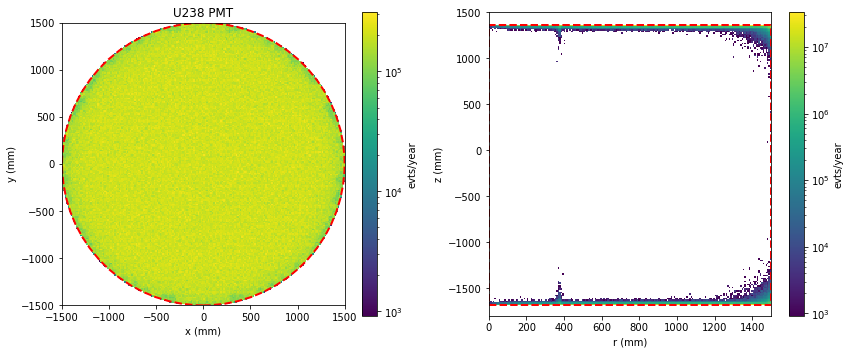

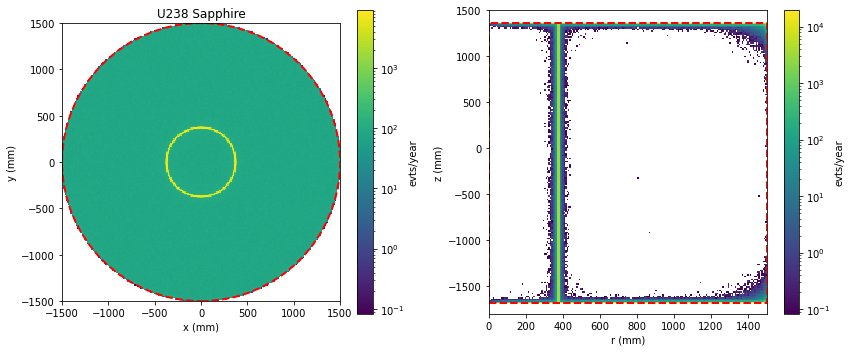

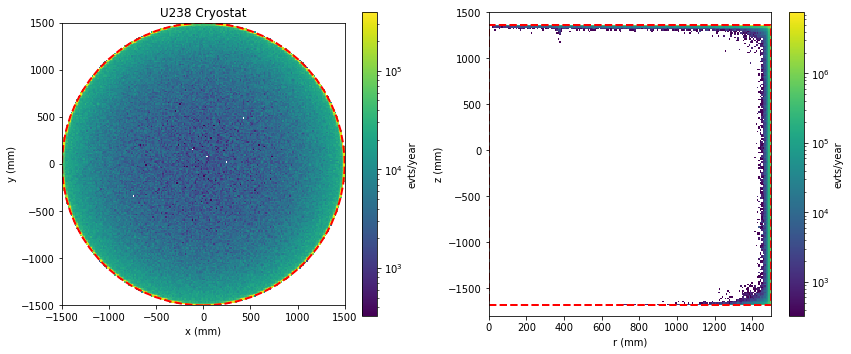

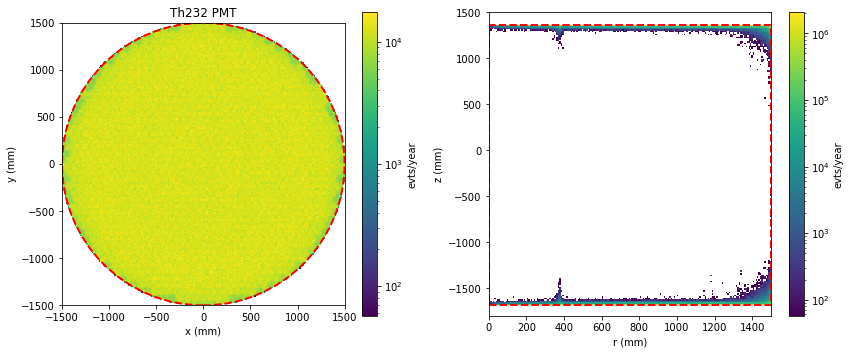

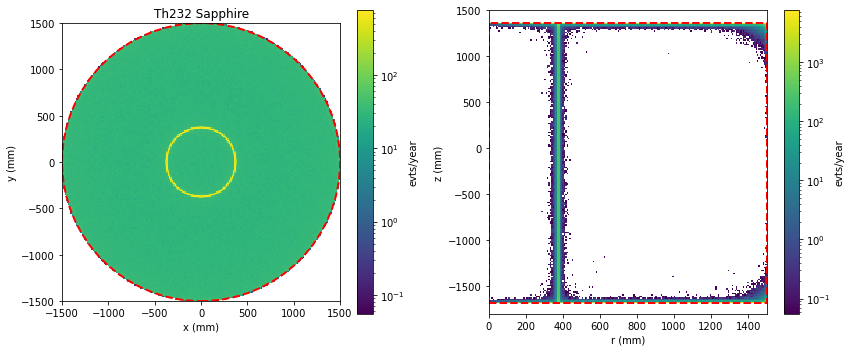

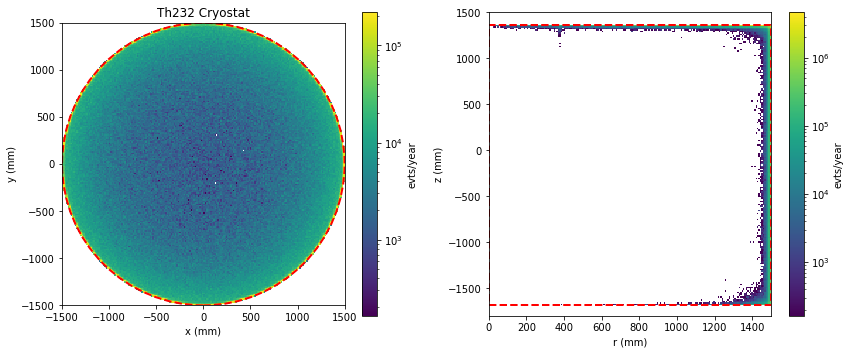

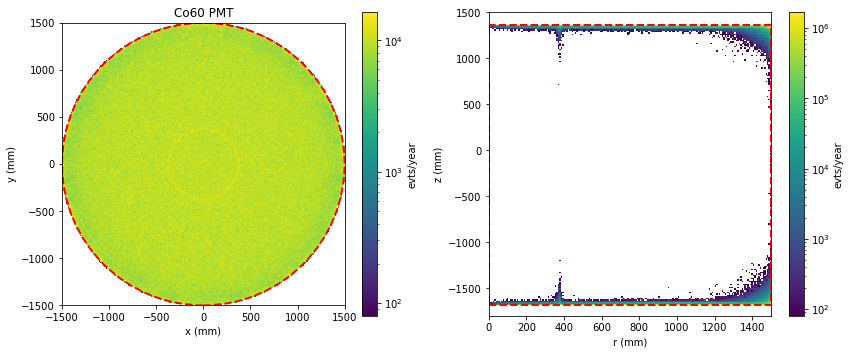

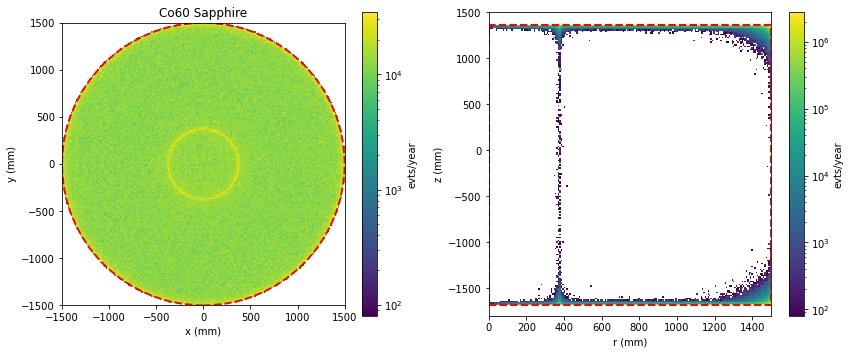

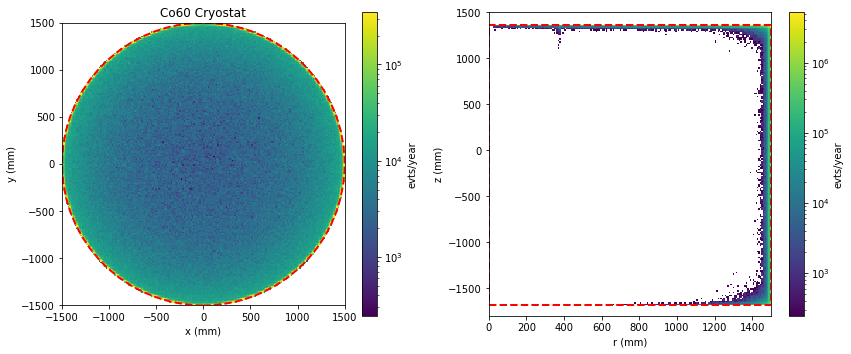

In [73]:
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

        pcm1 = ax1.pcolormesh(*iso_data["h_xy_ss_energy"].axes.edges.T, iso_data["h_xy_ss_energy"].values().T*iso_data['scale_factor'], norm=matplotlib.colors.LogNorm())
        ax1.add_patch(plt.Circle((0, 0), fv_radius, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))

        ax1.set_title(f"{material} {isotope}")
        ax1.set_xlabel("x (mm)")
        ax1.set_ylabel("y (mm)")
        ax1.set_aspect('equal', adjustable='box')

        pcm2 = ax2.pcolormesh(*iso_data["h_rz_ss_energy"].axes.edges.T, iso_data["h_rz_ss_energy"].values().T*iso_data['scale_factor'], norm=matplotlib.colors.LogNorm())
        ax2.add_patch(plt.Rectangle((-0, fv_z[0]), fv_radius, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

        ax2.set_xlabel("r (mm)")
        ax2.set_ylabel("z (mm)")

        plt.colorbar(pcm1, label="evts/year")
        plt.colorbar(pcm2, label="evts/year")
        fig.tight_layout()
        plt.show()

### Sum All Histograms

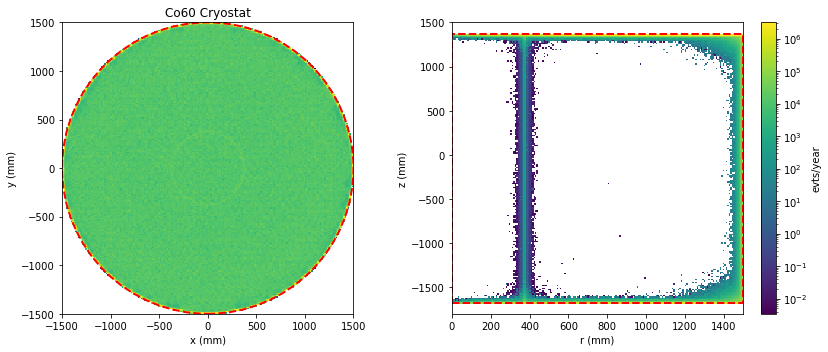

In [90]:
del h_xy_total
del h_rz_total
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        try:
            h_xy_total
        except NameError:
            h_xy_total = iso_data["h_xy_ss_energy"].copy()
            h_xy_total.reset()
        try:
            h_rz_total
        except:
            h_rz_total = iso_data["h_rz_ss_energy"].copy()
            h_rz_total.reset()
        
        h_xy_total += iso_data["h_xy_ss_energy"]*iso_data['scale_factor']
        h_rz_total += iso_data["h_rz_ss_energy"]*iso_data['scale_factor']
        
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

pcm1 = ax1.pcolormesh(*h_xy_total.axes.edges.T, h_xy_total.values().T, norm=matplotlib.colors.LogNorm())
ax1.add_patch(plt.Circle((0, 0), fv_radius, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))

ax1.set_title("Total ER")
ax1.set_xlabel("x (mm)")
ax1.set_ylabel("y (mm)")
ax1.set_aspect('equal', adjustable='box')

pcm1 = ax2.pcolormesh(*h_rz_total.axes.edges.T, h_rz_total.values().T, norm=matplotlib.colors.LogNorm())
ax2.add_patch(plt.Rectangle((-0, fv_z[0]), fv_radius, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

ax2.set_xlabel("r (mm)")
ax2.set_ylabel("z (mm)")

plt.colorbar(pcm1, label="evts/year")
plt.colorbar(pcm2, label="evts/year")
fig.tight_layout()
plt.show()

In [91]:
h_rz_total

Histogram(
  Regular(200, 0, 1500),
  Regular(200, -1800, 1500),
  storage=Double()) # Sum: 513583496.8074372

### Mass Volume Normalization histogram

In [126]:
h_vol = h_rz_total.copy()
h_vol.reset()

r_edges = h_rz_total.axes[0].edges
z_edges = h_rz_total.axes[1].edges

dr2 = np.diff(r_edges**2)  
dz  = np.diff(z_edges)    
volumes = np.pi * dr2[:, np.newaxis] * dz

h_vol.view()[:] = volumes*LXe['density']/1e9 #(1e6  to convert to tonne)

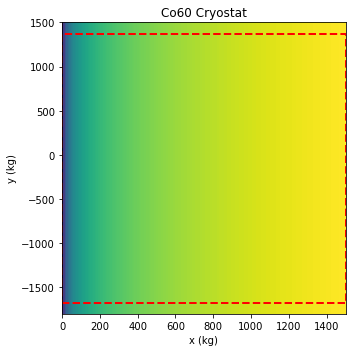

In [127]:
fig, (ax2) = plt.subplots(nrows=1, ncols=1, figsize=(5,5))

pcm1 = ax2.pcolormesh(*h_vol.axes.edges.T, h_vol.values().T, norm=matplotlib.colors.LogNorm())
ax2.add_patch(plt.Rectangle((-0, fv_z[0]), fv_radius, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

ax2.set_title(f"{material} {isotope}")
ax2.set_xlabel("x (kg)")
ax2.set_ylabel("y (kg)")

plt.colorbar(pcm2, label="mass")
fig.tight_layout()
plt.show()

### Normalize Total Histogram

In [94]:
h_rz_norm = h_rz_total/h_vol

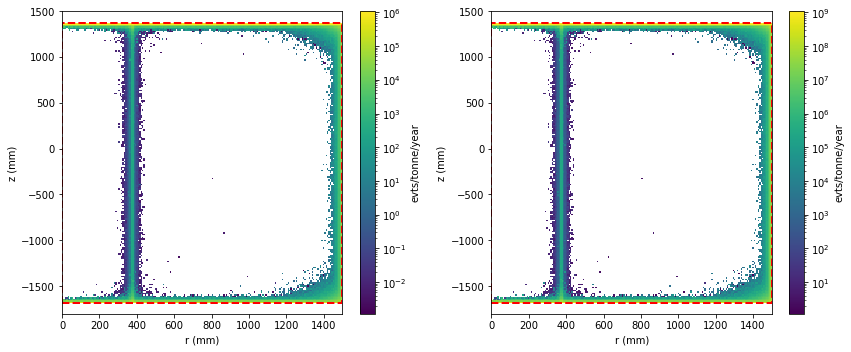

In [128]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

pcm1 = ax1.pcolormesh(*h_rz_norm.axes.edges.T, h_rz_norm.values().T, norm=matplotlib.colors.LogNorm())
ax1.add_patch(plt.Rectangle((-0, fv_z[0]), fv_radius, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

ax1.set_xlabel("r (mm)")
ax1.set_ylabel("z (mm)")

pcm2 = ax2.pcolormesh(*h_rz_total.axes.edges.T, (h_rz_total/h_vol).values().T, norm=matplotlib.colors.LogNorm())
ax2.add_patch(plt.Rectangle((-0, fv_z[0]), fv_radius, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

ax2.set_xlabel("r (mm)")
ax2.set_ylabel("z (mm)")

plt.colorbar(pcm1, label="evts/tonne/year")
plt.colorbar(pcm2, label="evts/tonne/year")
fig.tight_layout()
plt.show()

### Look at rate in R

In [147]:
h_r_slice = h_rz_norm[:, bh.loc(-1350):bh.loc(1250):bh.sum]

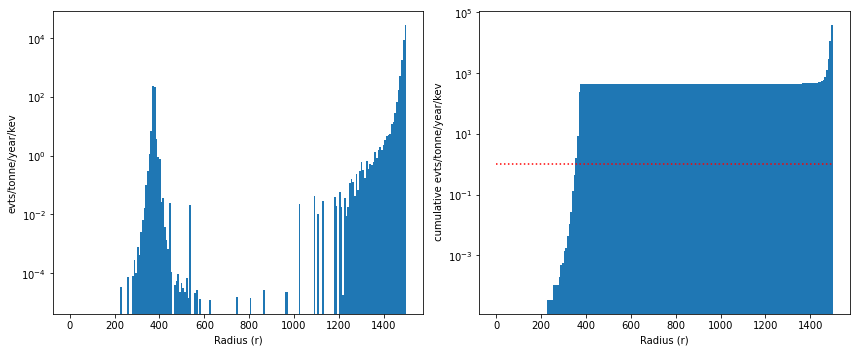

In [150]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

main_axis = h_r_slice.axes[0]
ax1.bar(main_axis.centers, h_r_slice.view()/200, width=main_axis.widths)
ax1.set_xlabel("Radius (r)")
ax1.set_ylabel("evts/tonne/year/kev")
ax1.set_yscale('log')

# Cumulative Plots
counts = h_r_slice.view()
cumulative_counts = np.cumsum(counts)

edges = h_r_slice.axes[0].edges
ax2.stairs(cumulative_counts/200, edges, fill=True)
ax2.set_yscale('log')
ax2.set_xlabel("Radius (r)")
ax2.set_ylabel(" cumulative evts/tonne/year/kev")

ax2.hlines(1, xmin=0, xmax=1500, linestyle =":", color='red')

fig.tight_layout()
plt.show()

In [171]:
h_r_slice = h_vol[:, bh.loc(-1350):bh.loc(1250):bh.sum]
print(np.sum(h_r_slice.counts()))

52.40655560527631


### Remove Sapphire Walls

In [166]:
h_rz_nosaph = h_rz_norm.copy()
r_start = h_rz_nosaph.axes[0].index(365.0)
r_end   = h_rz_nosaph.axes[0].index(415.0)
h_rz_nosaph.view(flow=True)[r_start:r_end, :] = 0
h_r_slice = h_rz_nosaph[:, bh.loc(-1350):bh.loc(1250):bh.sum]

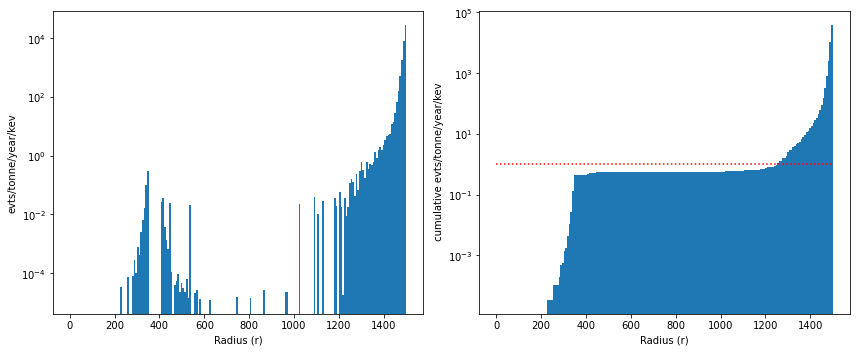

In [167]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

main_axis = h_r_slice.axes[0]
ax1.bar(main_axis.centers, h_r_slice.view()/200, width=main_axis.widths)
ax1.set_xlabel("Radius (r)")
ax1.set_ylabel("evts/tonne/year/kev")
ax1.set_yscale('log')

# Cumulative Plots
counts = h_r_slice.view()
cumulative_counts = np.cumsum(counts)

edges = h_r_slice.axes[0].edges
ax2.stairs(cumulative_counts/200, edges, fill=True)
ax2.set_yscale('log')
ax2.set_xlabel("Radius (r)")
ax2.set_ylabel("Cumulative evts/tonne/year/kev")

ax2.hlines(1, xmin=0, xmax=1500, linestyle =":", color='red')

fig.tight_layout()
plt.show()

In [170]:
h_rz_nosaph = h_vol.copy()
r_start = h_rz_nosaph.axes[0].index(365.0)
r_end   = h_rz_nosaph.axes[0].index(415.0)
h_rz_nosaph.view(flow=True)[r_start:r_end, :] = 0
h_r_slice = h_rz_nosaph[:, bh.loc(-1350):bh.loc(1250):bh.sum]
print(np.sum(h_r_slice.counts()))

51.48026973495305
